<a href="https://colab.research.google.com/github/dhunsyam/Advance-Databases/blob/gh-pages/notebooks/Geopandas%20full%20Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   UEMPRATE  cartodb_id  borocode  withssi  withsocial  withpubass  \
0  0.095785           1         3      652        5067         277   
1  0.090011           2         3     2089        7132        1016   
2  0.130393           3         3     3231        8847        2891   
3  0.086633           4         3     1103        3508         553   
4  0.099184           5         4      326        2229         132   

   struggling  profession  popunemplo  poptot  ...  boroname      popdty  \
0        6421         889        2225   48351  ...  Brooklyn  497498.701   
1       10981        1075        2652   61584  ...  Brooklyn  589296.926   
2       21235         712        6483  100130  ...  Brooklyn  1506628.84   
3        7188         475        1709   33155  ...  Brooklyn  468975.876   
4        5307         187        1276   24199  ...    Queens  125384.135   

   ntacode  medianinco  medianagem  medianagef  medianage            HHsize  \
0     BK45     1520979       663.3       77

<Axes: >

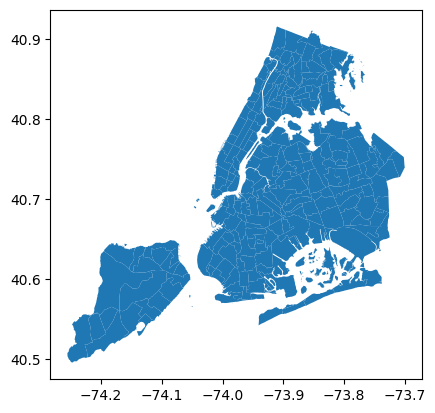

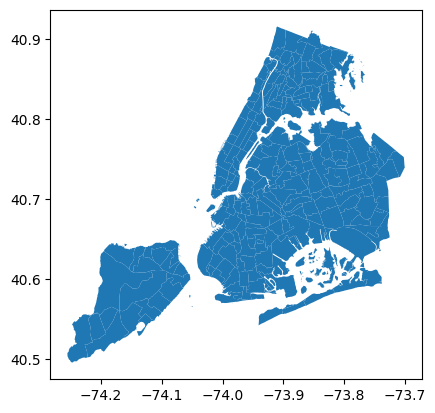

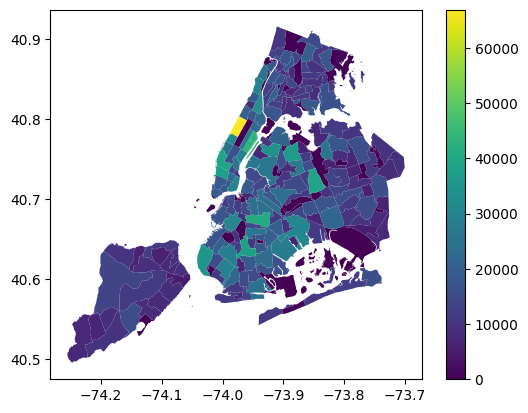

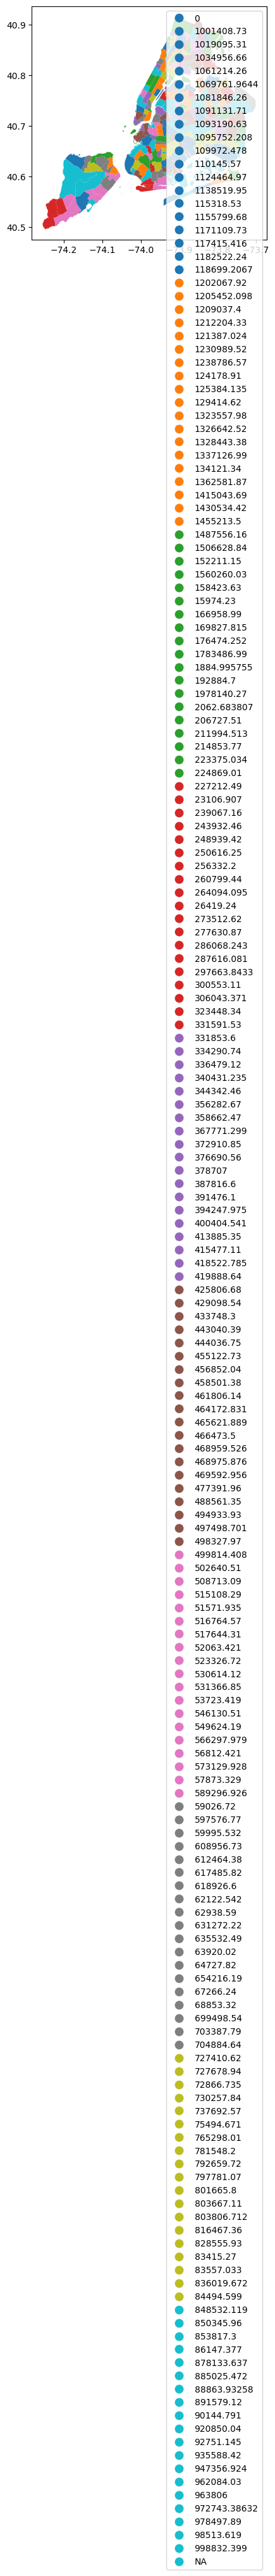

In [6]:
import geopandas as gpd

!pip install geodatasets # run this if needed

import geodatasets



#To see all datasets available, try the following:



geodatasets.data.flatten().keys()


geodatasets.data.geoda.nyc_neighborhoods

url = geodatasets.get_path('geoda.nyc_neighborhoods')

df = gpd.read_file(url)

print(df.head())

df.plot()

#Or

geodatasets.get_url('geoda.nyc_neighborhoods')

df = gpd.read_file(url)

print(df.head())

df.plot()



#install from zip file if need be and the above doesnt work
#zip = "nycnhood_acs.zip"

#df = gpd.read_file(zip)

#df.plot()


#check out the Geometry column

print(df['geometry'].iloc[0])

df['geometry'].iloc[0]


df.plot(column = 'households', legend = True)


df.plot(column = 'popdty', legend = True)

<Axes: >

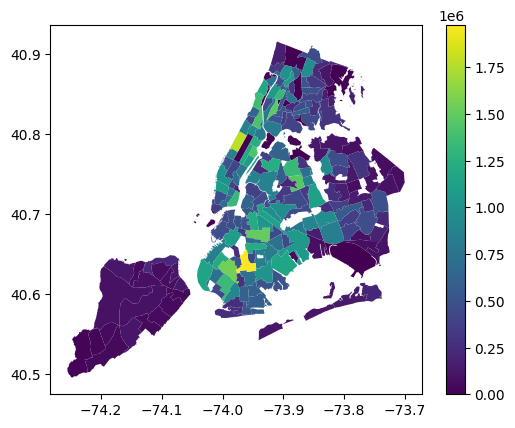

In [7]:
import pandas as pd

df['popdty'] = pd.to_numeric(df['popdty'], errors='coerce')  # Convert to float

df['popdty'] = df['popdty'].round(0)  # Round after conversion

df.plot(column='popdty', legend=True)

<Axes: >

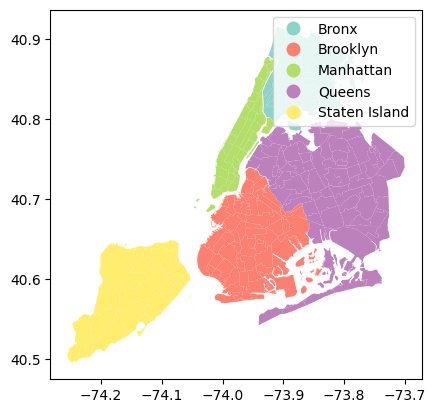

In [8]:
df.plot(column='boroname', cmap='Set3', legend=True)

<Axes: >

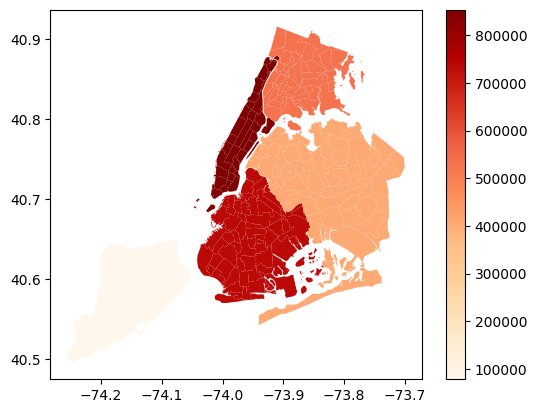

In [9]:
borough_avg = df.groupby('boroname')['popdty'].mean().to_dict()

df['borough_popdty'] = df['boroname'].map(borough_avg)

df.plot(column='borough_popdty', cmap='OrRd', legend=True, edgecolor=None)

[Text(0.5, 1.0, 'Average Population Density by Borough')]

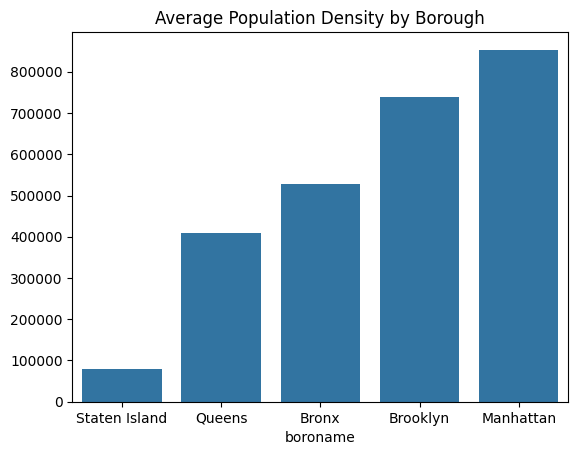

In [10]:
import seaborn as sns

sns.barplot(

    x=df.groupby('boroname')['popdty'].mean().sort_values().index,

    y=df.groupby('boroname')['popdty'].mean().sort_values().values

).set(title="Average Population Density by Borough")

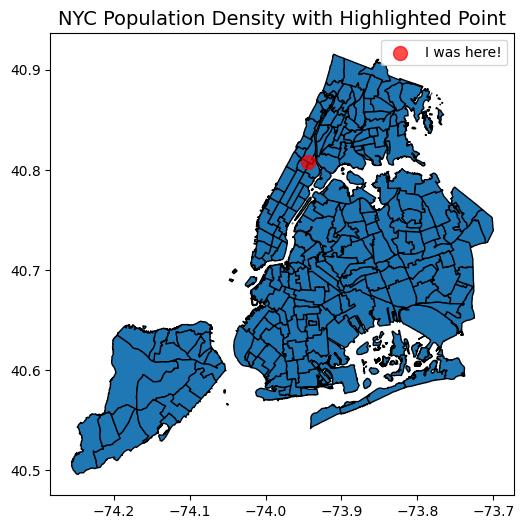

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

df.plot( cmap=None, legend=True, edgecolor='black', ax=ax)

ax.scatter(-73.9442, 40.8075, color='red', s=100, label="I was here!", alpha=0.7)

ax.set_title("NYC Population Density with Highlighted Point", fontsize=14)

ax.legend()

plt.show()